Dataset Shape: (20640, 8)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Ridge Regression Results
----------------------------------------
Alpha: 1.0
Training RMSE: 0.7197
Testing RMSE : 0.7456
Training R2  : 0.6126
Testing R2   : 0.5758

Analysis
----------------------------------------
Model has a reasonable bias-variance balance
Train-Test R2 Difference: 0.0367

Feature Coefficients:
      Feature  Coefficient
0      MedInc     0.854327
1    HouseAge     0.122624
2    AveRooms

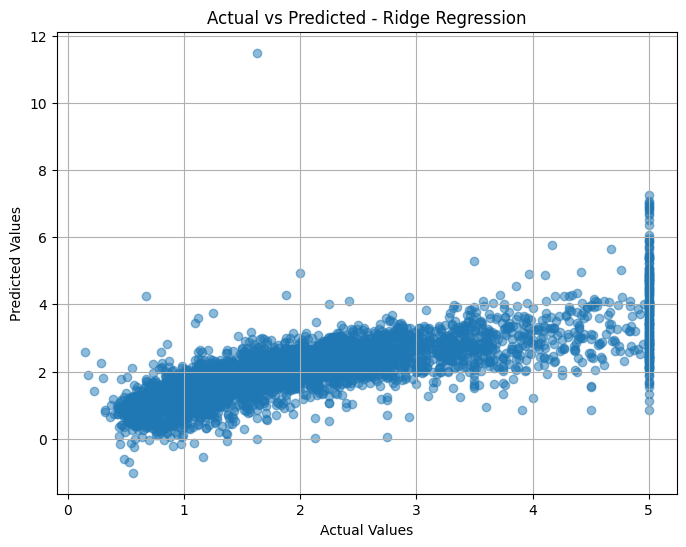

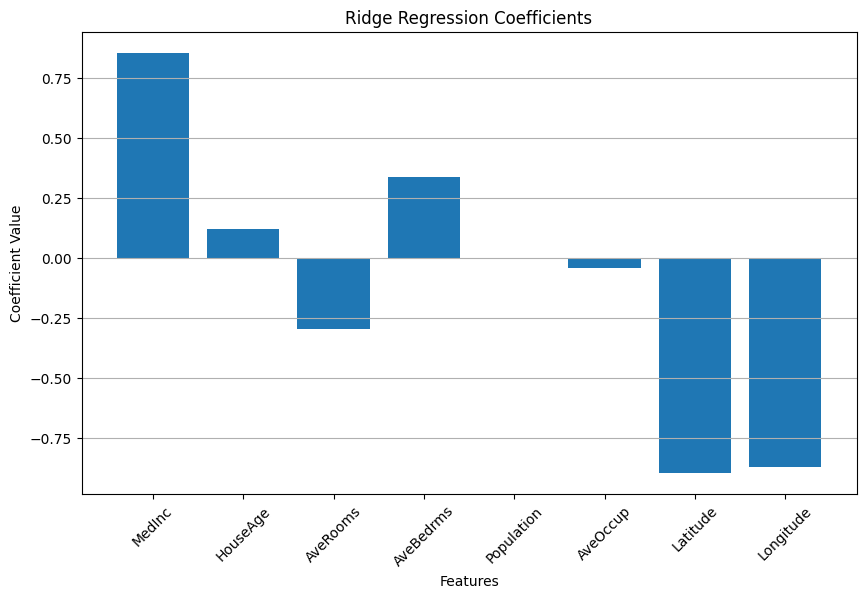

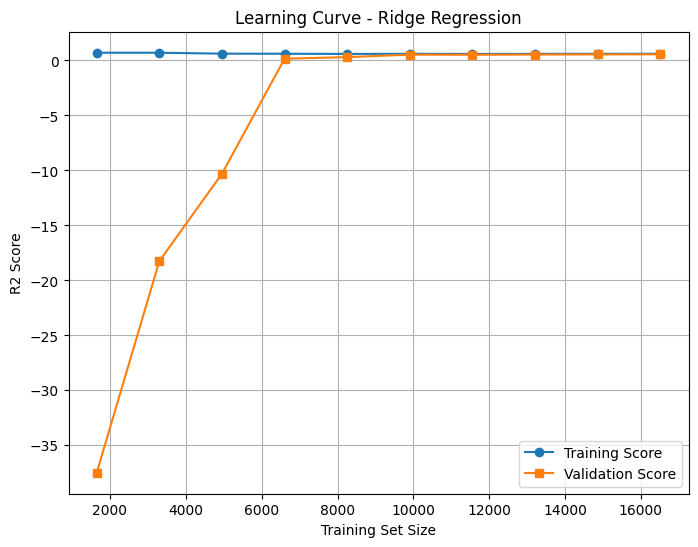


Alpha Comparison
------------------------------------------------------------
Alpha     Train R2       Test R2        Remarks
0.001     0.6126         0.5758         Balanced
0.01      0.6126         0.5758         Balanced
0.1       0.6126         0.5758         Balanced
1         0.6126         0.5758         Balanced
10        0.6125         0.5761         Balanced
100       0.6120         0.5778         Balanced


In [1]:
# Programming Assignment 33
# Ridge Regression considering bias, variance, overfitting and underfitting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# --------------------------------------------------
# 1. Load dataset
# --------------------------------------------------
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

print("Dataset Shape:", X.shape)
print("\nFirst 5 rows:")
print(X.head())

# --------------------------------------------------
# 2. Split dataset into training and testing sets
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------------
# 3. Standardize features
# --------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# 4. Train Ridge model
#    alpha controls regularization:
#    very high alpha -> underfitting
#    very low alpha  -> possible overfitting
# --------------------------------------------------
alpha_value = 1.0
ridge_model = Ridge(alpha=alpha_value)

ridge_model.fit(X_train_scaled, y_train)

# --------------------------------------------------
# 5. Predictions
# --------------------------------------------------
y_train_pred = ridge_model.predict(X_train_scaled)
y_test_pred = ridge_model.predict(X_test_scaled)

# --------------------------------------------------
# 6. Evaluation
# --------------------------------------------------
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nRidge Regression Results")
print("-" * 40)
print("Alpha:", alpha_value)
print("Training RMSE:", round(train_rmse, 4))
print("Testing RMSE :", round(test_rmse, 4))
print("Training R2  :", round(train_r2, 4))
print("Testing R2   :", round(test_r2, 4))

# --------------------------------------------------
# 7. Bias, Variance, Overfitting, Underfitting analysis
# --------------------------------------------------
print("\nAnalysis")
print("-" * 40)

if train_r2 < 0.6 and test_r2 < 0.6:
    print("Model shows HIGH BIAS -> likely UNDERFITTING")
elif train_r2 > 0.9 and (train_r2 - test_r2) > 0.1:
    print("Model shows HIGH VARIANCE -> likely OVERFITTING")
else:
    print("Model has a reasonable bias-variance balance")

print("Train-Test R2 Difference:", round(abs(train_r2 - test_r2), 4))

# --------------------------------------------------
# 8. Coefficients
# --------------------------------------------------
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_
})

print("\nFeature Coefficients:")
print(coef_df)

# --------------------------------------------------
# 9. Plot Actual vs Predicted
# --------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Ridge Regression")
plt.grid(True)
plt.show()

# --------------------------------------------------
# 10. Plot coefficients
# --------------------------------------------------
plt.figure(figsize=(10, 6))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.xticks(rotation=45)
plt.title("Ridge Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.grid(axis='y')
plt.show()

# --------------------------------------------------
# 11. Learning curve for bias and variance understanding
# --------------------------------------------------
X_scaled_full = StandardScaler().fit_transform(X)

train_sizes, train_scores, val_scores = learning_curve(
    Ridge(alpha=alpha_value),
    X_scaled_full,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_scores_mean, marker='s', label='Validation Score')
plt.xlabel("Training Set Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve - Ridge Regression")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# 12. Underfitting and overfitting comparison with different alpha values
# --------------------------------------------------
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

print("\nAlpha Comparison")
print("-" * 60)
print(f"{'Alpha':<10}{'Train R2':<15}{'Test R2':<15}{'Remarks'}")

for a in alpha_list:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    tr_r2 = r2_score(y_train, train_pred)
    te_r2 = r2_score(y_test, test_pred)

    if tr_r2 < 0.6 and te_r2 < 0.6:
        remark = "Underfitting"
    elif tr_r2 - te_r2 > 0.1:
        remark = "Overfitting"
    else:
        remark = "Balanced"

    print(f"{a:<10}{tr_r2:<15.4f}{te_r2:<15.4f}{remark}")